In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spx = pd.read_csv("../data/spx.csv", index_col=0, parse_dates=True)
stable = pd.read_csv("../data/stable.csv", index_col=0, parse_dates=True)
tech = pd.read_csv("../data/tech.csv", index_col=0, parse_dates=True)
btc = pd.read_csv("../data/btc.csv", index_col=0, parse_dates=True)

for name, df in [("SPX", spx), ("Stable", stable), ("Tech", tech), ("BTC", btc)]:
    print(f"{name} columns: {list(df.columns)}")

SPX columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Stable columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Tech columns: ['Close', 'High', 'Low', 'Open', 'Volume']
BTC columns: ['Close', 'High', 'Low', 'Open', 'Volume']


In [2]:
def garman_klass(df):
    log_hl = np.log(df["High"] / df["Low"])
    log_co = np.log(df["Close"] / df["Open"])
    
    gk_variance = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    return gk_variance

In [3]:
def parkinson(df):
    log_hl = np.log(df["High"] / df["Low"])
    
    parkinson_variance = (1 / (4 * np.log(2))) * log_hl**2
    return parkinson_variance

In [4]:
spx_var = garman_klass(spx)
stable_var = garman_klass(stable)
tech_var = garman_klass(tech)
btc_var = parkinson(btc)

for name, var in [("SPX", spx_var), ("Stable", stable_var), ("Tech", tech_var), ("BTC", btc_var)]:
    print(f"{name} daily variance sample:\n{var.head()}\n")

SPX daily variance sample:
Date
2017-01-03    0.000032
2017-01-04    0.000006
2017-01-05    0.000012
2017-01-06    0.000029
2017-01-09    0.000003
dtype: float64

Stable daily variance sample:
Date
2017-01-03    0.000061
2017-01-04    0.000030
2017-01-05    0.000030
2017-01-06    0.000021
2017-01-09    0.000038
dtype: float64

Tech daily variance sample:
Date
2017-01-03    0.002103
2017-01-04    0.000701
2017-01-05    0.000781
2017-01-06    0.000439
2017-01-09    0.000409
dtype: float64

BTC daily variance sample:
Date
2017-01-01    0.000739
2017-01-02    0.000422
2017-01-03    0.000171
2017-01-04    0.003937
2017-01-05    0.026046
dtype: float64



In [6]:
spx_vol = np.sqrt(spx_var.rolling(window=21).mean())
stable_vol = np.sqrt(stable_var.rolling(window=21).mean())
tech_vol = np.sqrt(tech_var.rolling(window=21).mean())
btc_vol = np.sqrt(btc_var.rolling(window=21).mean())

for name, vol in [("SPX", spx_vol), ("Stable", stable_vol), ("Tech", tech_vol), ("BTC", btc_vol)]:
    print(f"{name} rolling vol sample:\n{vol.dropna().head()}\n")

SPX rolling vol sample:
Date
2017-02-01    0.003892
2017-02-02    0.003778
2017-02-03    0.003769
2017-02-06    0.003728
2017-02-07    0.003588
dtype: float64

Stable rolling vol sample:
Date
2017-02-01    0.005445
2017-02-02    0.005247
2017-02-03    0.005253
2017-02-06    0.005214
2017-02-07    0.005205
dtype: float64

Tech rolling vol sample:
Date
2017-02-01    0.021278
2017-02-02    0.019270
2017-02-03    0.018536
2017-02-06    0.017637
2017-02-07    0.017469
dtype: float64

BTC rolling vol sample:
Date
2017-01-21    0.057570
2017-01-22    0.057547
2017-01-23    0.057396
2017-01-24    0.057509
2017-01-25    0.055881
dtype: float64



In [7]:
spx_vol_annualized = spx_vol * np.sqrt(252)
stable_vol_annualized = stable_vol * np.sqrt(252)
tech_vol_annualized = tech_vol * np.sqrt(252)
btc_vol_annualized = btc_vol * np.sqrt(252)

for name, vol in [("SPX", spx_vol_annualized), ("Stable", stable_vol_annualized), 
                   ("Tech", tech_vol_annualized), ("BTC", btc_vol_annualized)]:
    print(f"{name} annualized vol sample:\n{(vol.dropna() * 100).head()}\n")

SPX annualized vol sample:
Date
2017-02-01    6.177712
2017-02-02    5.997679
2017-02-03    5.983690
2017-02-06    5.917677
2017-02-07    5.696460
dtype: float64

Stable annualized vol sample:
Date
2017-02-01    8.643757
2017-02-02    8.328924
2017-02-03    8.339157
2017-02-06    8.277081
2017-02-07    8.262516
dtype: float64

Tech annualized vol sample:
Date
2017-02-01    33.777579
2017-02-02    30.589621
2017-02-03    29.424834
2017-02-06    27.997625
2017-02-07    27.731127
dtype: float64

BTC annualized vol sample:
Date
2017-01-21    91.389421
2017-01-22    91.353780
2017-01-23    91.113209
2017-01-24    91.292829
2017-01-25    88.708146
dtype: float64



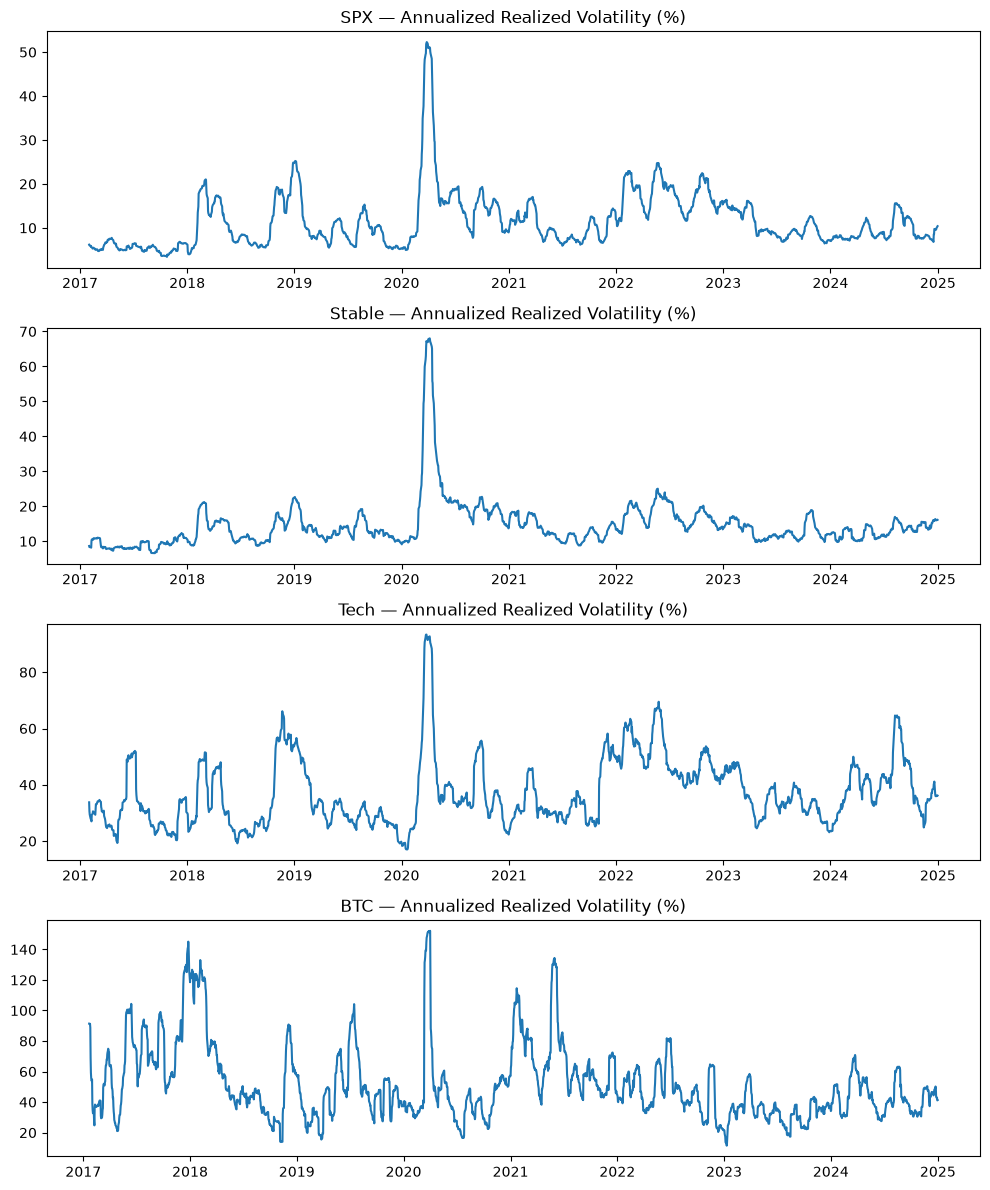

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
for ax, (name, vol) in zip(axes, [("SPX", spx_vol_annualized), ("Stable", stable_vol_annualized), 
                                     ("Tech", tech_vol_annualized), ("BTC", btc_vol_annualized)]):
    ax.plot(vol.index, vol * 100)
    ax.set_title(f"{name} — Annualized Realized Volatility (%)")
plt.tight_layout()
plt.show()

In [10]:
vol_targets = pd.DataFrame({
    "spx": spx_vol_annualized,
    "stable": stable_vol_annualized,
    "tech": tech_vol_annualized,
    "btc": btc_vol_annualized
}).dropna() * 100

vol_targets.to_csv("../data/realized_volatility.csv")
print(f"Saved {len(vol_targets)} rows to realized_volatility.csv")
vol_targets.head()

Saved 1992 rows to realized_volatility.csv


,spx,stable,tech,btc
Date,,,,
2017-02-01,6.177712,8.643757,33.777579,38.833879
2017-02-02,5.997679,8.328924,30.589621,34.695389
2017-02-03,5.983690,8.339157,29.424834,32.699031
2017-02-06,5.917677,8.277081,27.997625,32.931122
2017-02-07,5.696460,8.262516,27.731127,27.190163
